##Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import shap
import joblib

##Load Dataset

In [3]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

##Data Cleaning

In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

In [6]:
df.drop("customerID", axis=1, inplace=True)

##Encode Categorical Columns

In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [8]:
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

## EDA

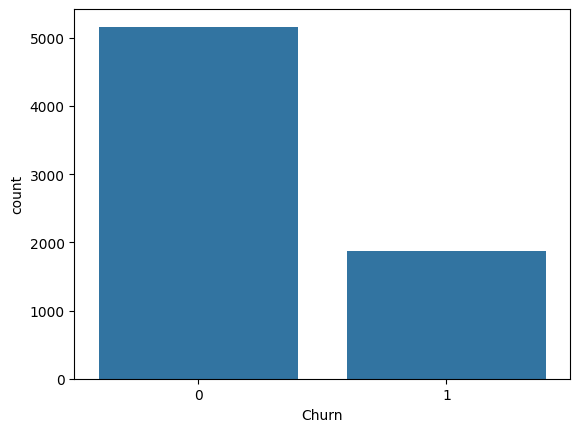

In [9]:
sns.countplot(x="Churn", data=df)
plt.show()

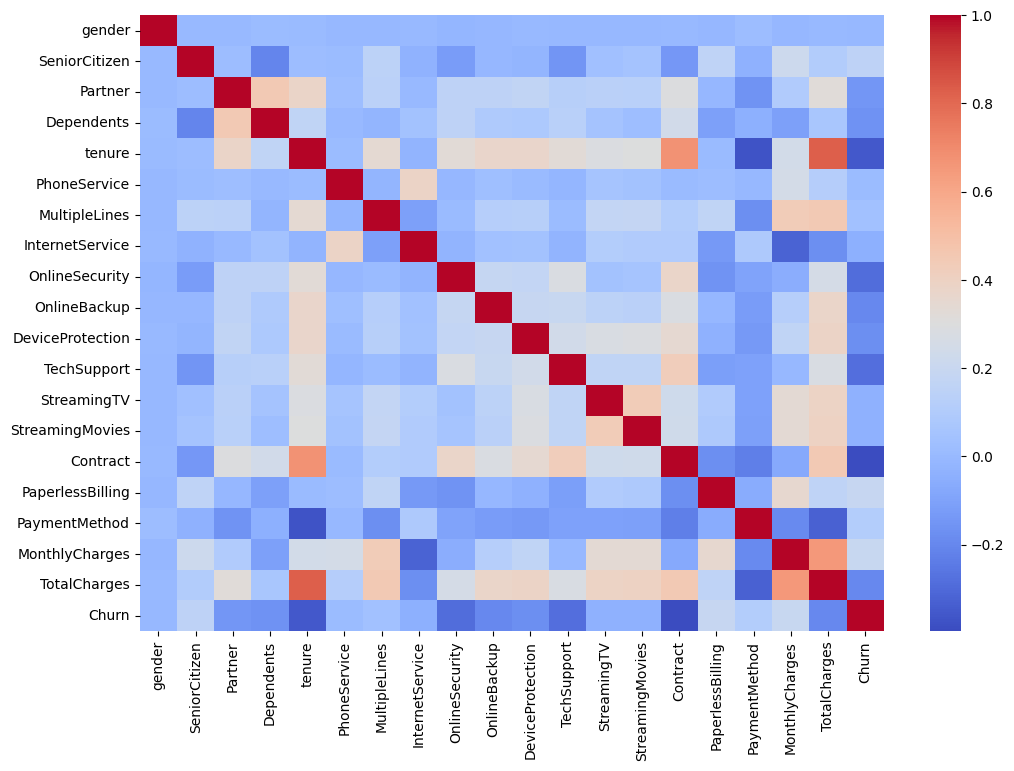

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

##Define Features and Target

In [11]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

##Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Build XGBoost Model

In [14]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

## Predictions

In [15]:
y_pred = model.predict(X_test)

## Evaluation

In [17]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 78.82%


##Classification Report

In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



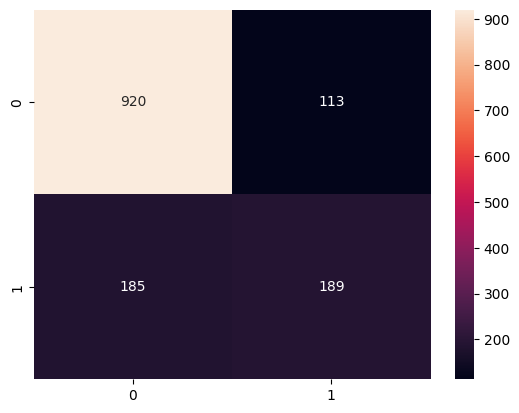

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

##Feature Importance

In [20]:
importance = model.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_df.head(10))

            Feature  Importance
14         Contract    0.433922
8    OnlineSecurity    0.112667
7   InternetService    0.103129
11      TechSupport    0.058153
4            tenure    0.031072
17   MonthlyCharges    0.023496
1     SeniorCitizen    0.022852
12      StreamingTV    0.021448
6     MultipleLines    0.020010
5      PhoneService    0.019811


###SHAP
##Why prediction happened
##Which features influenced churn
##Global feature importance
##Individual customer explanation

In [21]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

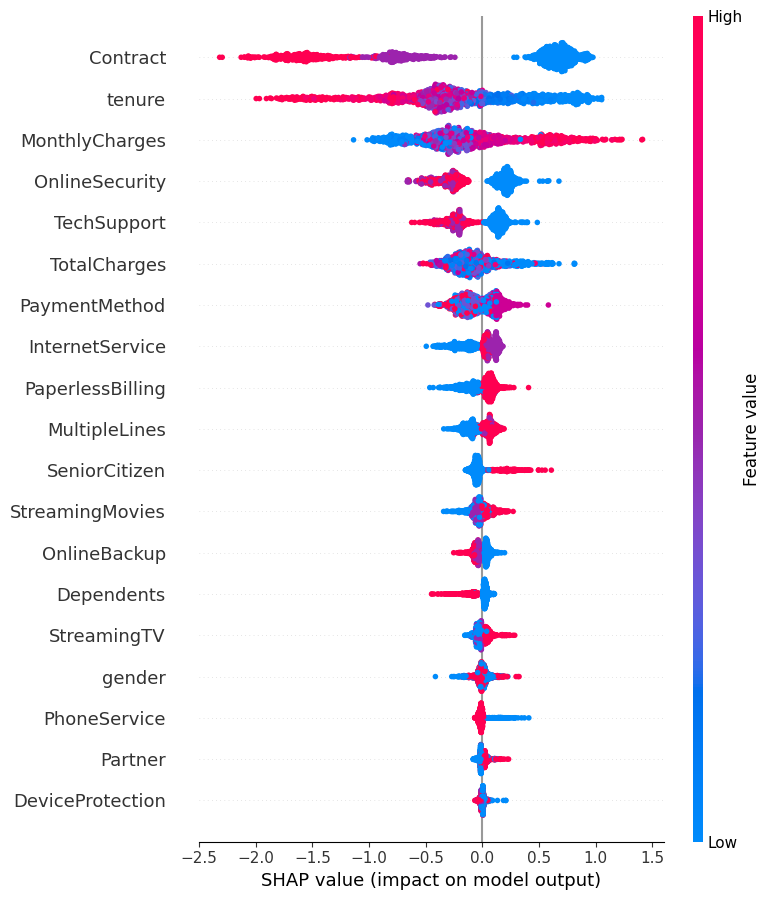

In [22]:
shap.summary_plot(
    shap_values,
    X_test
)

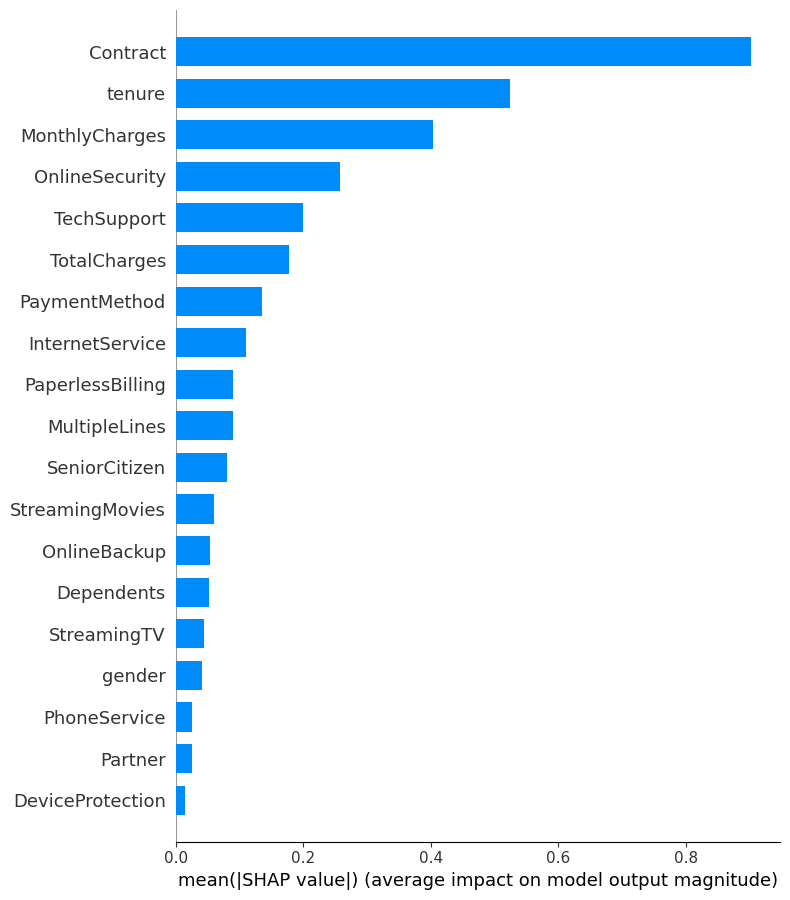

In [23]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

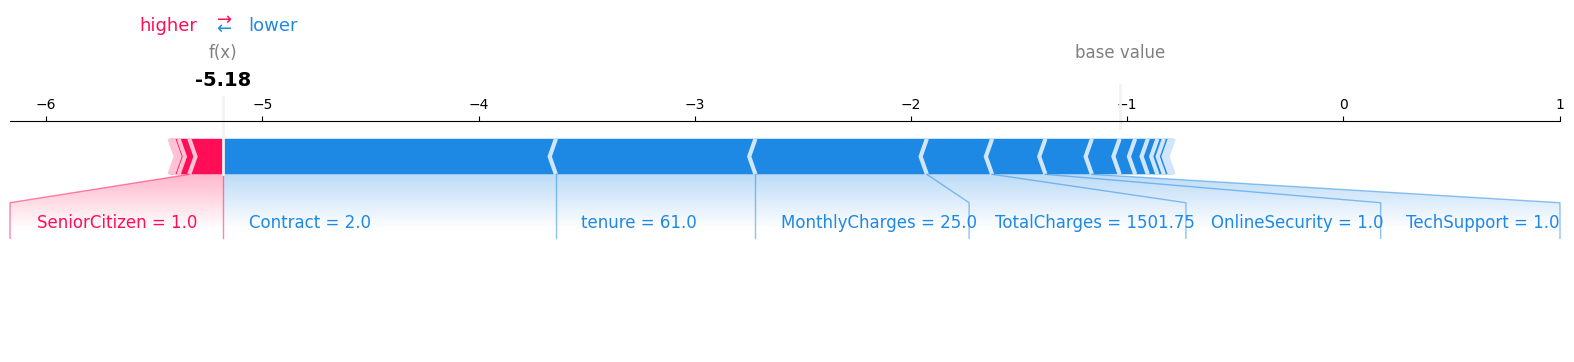

In [24]:
customer = X_test.iloc[[0]]

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    customer,
    matplotlib=True
)

##Save Model

In [25]:
joblib.dump(
    model,
    "churn_model.pkl"
)

['churn_model.pkl']

##Load Model

In [26]:
model = joblib.load(
    "churn_model.pkl"
)

##Predict New Customer

In [27]:
new_customer = [[
    1,0,0,1,1,0,
    12,1,1,0,0,
    0,1,0,0,0,
    60.5,720
]]

prediction = model.predict(
    new_customer
)

print(prediction)

ValueError: Feature shape mismatch, expected: 19, got 18

##Deployment

In [48]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# 1. Load the trained model
model = joblib.load("churn_model.pkl")

st.set_page_config(page_title="Customer Churn Prediction", layout="centered")
st.title("📊 Telecom Customer Churn Predictor")
st.write("Fill in the customer attributes below to evaluate churn risk and view retention plans.")

# 2. Recreate input layout for all 19 features in training order
st.header("Customer Demographics & Services")

col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Female", "Male"], index=0)
    senior_citizen = st.selectbox("Senior Citizen", ["No", "Yes"], index=0)
    partner = st.selectbox("Has Partner?", ["No", "Yes"], index=0)
    dependents = st.selectbox("Has Dependents?", ["No", "Yes"], index=0)
    tenure = st.number_input("Tenure (Months)", min_value=0, max_value=100, value=12)
    phone_service = st.selectbox("Phone Service", ["No", "Yes"], index=1)
    multiple_lines = st.selectbox("Multiple Lines", ["No", "No phone service", "Yes"], index=0)

with col2:
    internet_service = st.selectbox("Internet Service Type", ["DSL", "Fiber optic", "No"], index=1)
    online_security = st.selectbox("Online Security", ["No", "No internet service", "Yes"], index=0)
    online_backup = st.selectbox("Online Backup", ["No", "No internet service", "Yes"], index=0)
    device_protection = st.selectbox("Device Protection", ["No", "No internet service", "Yes"], index=0)
    tech_support = st.selectbox("Tech Support", ["No", "No internet service", "Yes"], index=0)
    streaming_tv = st.selectbox("Streaming TV", ["No", "No internet service", "Yes"], index=0)
    streaming_movies = st.selectbox("Streaming Movies", ["No", "No internet service", "Yes"], index=0)

st.header("Billing & Contract Account Details")
col3, col4 = st.columns(2)

with col3:
    contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"], index=0)
    paperless_billing = st.selectbox("Paperless Billing", ["No", "Yes"], index=1)
    payment_method = st.selectbox("Payment Method", ["Bank transfer (automatic)", "Credit card (automatic)", "Electronic check", "Mailed check"], index=2)

with col4:
    monthly_charges = st.number_input("Monthly Charges ($)", min_value=0.0, value=65.0, step=0.1)
    total_charges = st.number_input("Total Charges ($)", min_value=0.0, value=780.0, step=1.0)

# 3. Map categorical selections back to LabelEncoder integers
gender_map = {"Female": 0, "Male": 1}
binary_map = {"No": 0, "Yes": 1}
multi_map = {"No": 0, "No phone service": 1, "No internet service": 1, "Yes": 2}
internet_map = {"DSL": 0, "Fiber optic": 1, "No": 2}
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
payment_map = {"Bank transfer (automatic)": 0, "Credit card (automatic)": 1, "Electronic check": 2, "Mailed check": 3}

# Assemble the precise 19-element feature list
feature_values = [
    gender_map[gender],
    binary_map[senior_citizen],
    binary_map[partner],
    binary_map[dependents],
    int(tenure),
    binary_map[phone_service],
    multi_map[multiple_lines],
    internet_map[internet_service],
    multi_map[online_security],
    multi_map[online_backup],
    multi_map[device_protection],
    multi_map[tech_support],
    multi_map[streaming_tv],
    multi_map[streaming_movies],
    contract_map[contract],
    binary_map[paperless_billing],
    payment_map[payment_method],
    float(monthly_charges),
    float(total_charges)
]

# 4. Prediction Execution
if st.button("Analyze Churn Risk", type="primary"):
    input_data = np.array([feature_values])

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.markdown("---")
    st.subheader("Analysis Results")

    if prediction == 1:
        st.error(f"⚠️ **High Churn Risk Detector!** (Probability: {probability * 100:.2f}%)")

        # Actionable Business Recommendation Engine
        st.warning("### 📋 AI Retention Strategy Recommendation:")
        if contract_map[contract] == 0:
            st.write("- **Contract Incentive:** Customer is on a month-to-month plan. Offer a 15% discount if they upgrade to a 1-year stable contract.")
        if multi_map[tech_support] == 0 and internet_map[internet_service] != 2:
            st.write("- **Support Upgrades:** Customer does not have Tech Support enabled. Provide 3 months of complimentary Technical Support setup.")
    else:
        st.success(f"✅ **Low Churn Risk Customer.** (Probability: {probability * 100:.2f}%)")
        st.write("Customer shows strong healthy account trends. Maintain normal outreach.")

Overwriting app.py


In [52]:
%%writefile requirements.txt
streamlit
xgboost
joblib
numpy

Writing requirements.txt
